In [1]:
from checkers import MiniMaxGameBot, GameState, GameNode, new_board
from copy import deepcopy
from math import inf

In [2]:
import matplotlib.pyplot as plt

In [11]:
MAX_ROUNDS = 400

In [12]:
def play_game(bot_max_depth: int, bot_mini_depth: int) -> list["GameState"]:
    game = GameState()
    bot_max = MiniMaxGameBot(GameNode(game, 0), bot_max_depth)
    bot_mini = MiniMaxGameBot(GameNode(game, 0), bot_mini_depth)
    history = [deepcopy(game)]
    for i in range(MAX_ROUNDS):
        if i%100 == 0:
            print(f"Processing round {i}...")
        bot = bot_max if game.current_player == "r" else bot_mini
        game = bot.minimax_move(i == 0, game)
        if game is None:
            break
        history.append(deepcopy(game))
        
    return history

In [13]:
history = play_game(1, 6)
print(history[-1])

Processing round 0...
+-curr:r-+
| b     B|
|        |
|        |
|        |
|        |
|        |
|        |
|        |
+-|-inf|-+


In [6]:
for state in history[-5:]:
    print(str(state))

+-curr:r-+
| b      |
|      r |
|        |
|    B   |
|        |
|        |
|        |
|        |
+-|-1.5|-+
+-curr:b-+
| b     R|
|        |
|        |
|    B   |
|        |
|        |
|        |
|        |
+-|-1.0|-+
+-curr:r-+
| b     R|
|        |
|     B  |
|        |
|        |
|        |
|        |
|        |
+-|-1.0|-+
+-curr:b-+
| b      |
|      R |
|     B  |
|        |
|        |
|        |
|        |
|        |
+-|-1.0|-+
+-curr:r-+
| b     B|
|        |
|        |
|        |
|        |
|        |
|        |
|        |
+-|-inf|-+


In [14]:
DEPTH=6
History = list[GameState]
games: list[list[History]] = [[play_game(max_depth, mini_depth) for mini_depth in range(1, DEPTH+1)] for max_depth in range(1, DEPTH+1)]


Processing round 0...
Processing round 0...
Processing round 0...
Processing round 100...
Processing round 200...
Processing round 300...
Processing round 0...
Processing round 0...
Processing round 100...
Processing round 200...
Processing round 300...
Processing round 0...
Processing round 0...
Processing round 100...
Processing round 200...
Processing round 300...
Processing round 0...
Processing round 100...
Processing round 200...
Processing round 300...
Processing round 0...
Processing round 100...
Processing round 200...
Processing round 300...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 0...
Processing round 100...
Processing round 200...
Processing round 300...
Processing round 0...
Processing round 100...
Processing round 200...
Processing round 300...
Processing round 0...
Processing round 0...
Processing round 100...
Processing round 200...
Processing round 300...
Processing round 0...
Proces

In [17]:
games_final_scores = [[history[-1].score for history in row] for row in games]
print(*games_final_scores, sep='\n')

[-inf, -inf, -1.5, -inf, 0.5, -inf]
[2.0, -6.5, 4.0, 6.0, inf, inf]
[inf, inf, 1.0, 5.0, 7.5, 3.5]
[-0.5, 4.0, 7.0, -1.5, 0.5, -inf]
[-2.5, 0.0, -1.0, -2.0, 0.5, -inf]
[-1.0, 1.0, 0.0, -2.0, 0.5, -inf]


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def plot_final_scores(final_scores: list[list[float]]) -> None:
    A = np.asarray(final_scores, dtype=float)
    n_rows, n_cols = A.shape

    finite = A[np.isfinite(A)]
    v = float(np.max(np.abs(finite))) if finite.size else 1.0
    v = 1.0 if v == 0 else v  # avoid degenerate norm

    # For coloring only: clip infinities to the finite range
    A_c = np.clip(A, -v, v)
    norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)

    fig, ax = plt.subplots(figsize=(0.9 * n_cols + 2.0, 0.9 * n_rows + 1.5))
    im = ax.imshow(A_c, cmap="RdBu_r", norm=norm, origin="upper")

    cbar = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.9)
    cbar.set_label("Final score (r + / b –)  [clipped for color]")

    ax.set_title("MiniMax vs MiniMax — Final scores")
    ax.set_xlabel("b depth")
    ax.set_ylabel("r depth")
    ax.set_xticks(range(n_cols), labels=[str(j + 1) for j in range(n_cols)])
    ax.set_yticks(range(n_rows), labels=[str(i + 1) for i in range(n_rows)])

    # Cell grid
    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Annotations
    for i in range(n_rows):
        for j in range(n_cols):
            val = A[i, j]
            if np.isposinf(val):
                txt = "r win"
            elif np.isneginf(val):
                txt = "b win"
            else:
                txt = f"{val:.1f}"

            # Contrast-aware text color
            text_color = "white" if abs(A_c[i, j]) > 0.6 * v else "black"
            ax.text(j, i, txt, ha="center", va="center", fontsize=9, color=text_color)

    fig.tight_layout()

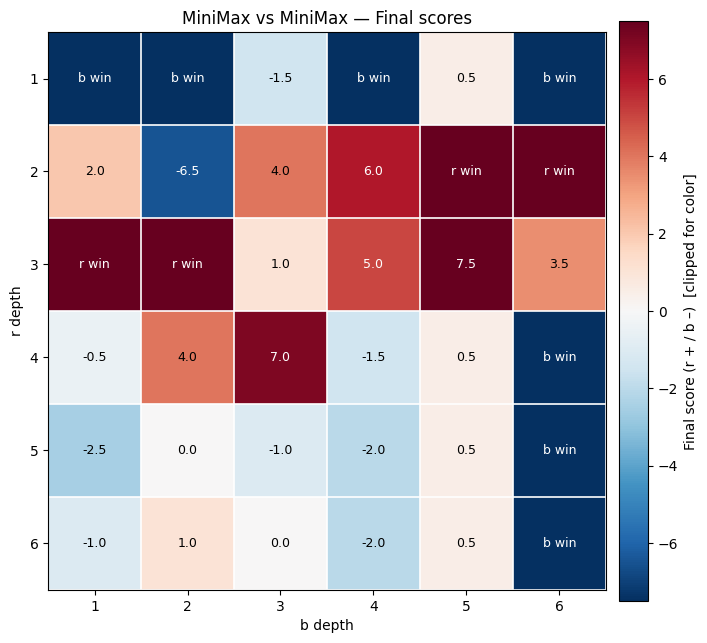

In [18]:
plot_final_scores(games_final_scores)